# Alignment Integration

Temporal alignment between source speech timing and target-language TTS audio.
This is the hard problem: a 3-second English phrase might take 5 seconds in Spanish.

Covers segment metrics, fallback policy, and global timeline optimization.

## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers
IMAGES_DIR:   /home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers/notebooks/alignment_integration/images


## Load Cached Transcripts

Load from `pipeline_data` (no API call needed).

In [2]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[0]
es_path = es_files[0]
print(en_path)

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

/home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers/pipeline_data/api/transcriptions/whisper/Alysa Liu: The 60 Minutes Interview.json
EN transcript: Alysa Liu: The 60 Minutes Interview.json  (338 segments)
ES transcript: Alysa Liu: The 60 Minutes Interview.json  (338 segments)


## Segment Timing Metrics

Compute predicted stretch factor and overflow for each segment.

The syllable-based duration heuristic estimates TTS output length at ~4.5 syllables/second
for Romance languages (~15 chars/s). For each segment we compare the predicted TTS duration
against the source-language time window to get `predicted_stretch` (1.0 = perfect fit,
1.3 = 30% too long).

**Notice what happens:** many segments have stretch factors well above 1.0. The translator
doesn't know about the timing budget — it just rewrites text without considering how long
it takes to speak. This is the core problem you'll address in the tasks below.

In [3]:
from foreign_whispers import (
    AlignAction, AlignedSegment, SegmentMetrics,
    compute_segment_metrics, decide_action,
)

all_metrics = compute_segment_metrics(en_transcript, es_transcript)
bad = [m for m in all_metrics if m.predicted_stretch > 1.5]

print(f"Total segments : {len(all_metrics)}")
print(f"Stretch > 1.5x : {len(bad)}  ({100*len(bad)/max(len(all_metrics),1):.0f}%)")
print("\nWorst 5:")
for m in sorted(bad, key=lambda x: -x.predicted_stretch)[:5]:
    print(f"  seg {m.index:3d}  stretch={m.predicted_stretch:.2f}x  overflow={m.overflow_s:.1f}s")
    # print(f"    EN: {m.source_text[:55]}")
    # print(f"    ES: {m.translated_text[:55]}")
    # NOTE: MY EDITS
    print(f"    EN: {m.source_text}")
    print(f"    ES: {m.translated_text}")

Muy pocas personas se jubilan a los 16 años.
Entonces otra vez, pocas personas tienen carreras con
tantos giros como la figura americana skater
Alysa Leu. Después de ser el más joven
Campeón de mujeres de Estados Unidos en la historia a la edad
13, el Phenom sorprendió al mundo patinante
cuando abandonó abruptamente unos años
más tarde. Ahora 20 años, Alyssa ha vuelto.
y un favorito para ganar oro en el invierno
Olimpiadas el próximo mes. Su regreso a la
el deporte era casi tan sorprendente como ella
Salir de ella. Nadie sabía qué
espera cuando empezó a entrenar de nuevo,
pero de alguna manera en una noche del viernes pasado
Marcha en Boston, Alyssa Leu estaba liderando
en el Campeonato Mundial con uno
rendimiento para ir.
Era la patinadora final de la noche. A
El título mundial colgó en el equilibrio.
En segundos, estaba claro que estaba levantada.
hasta el momento
mientras la disco de Donna Summer pulsaba.
Alyssa Leu belissfully dashed around the
hielo, tejiendo combinaciones de salt

## Visualize Stretch Distribution

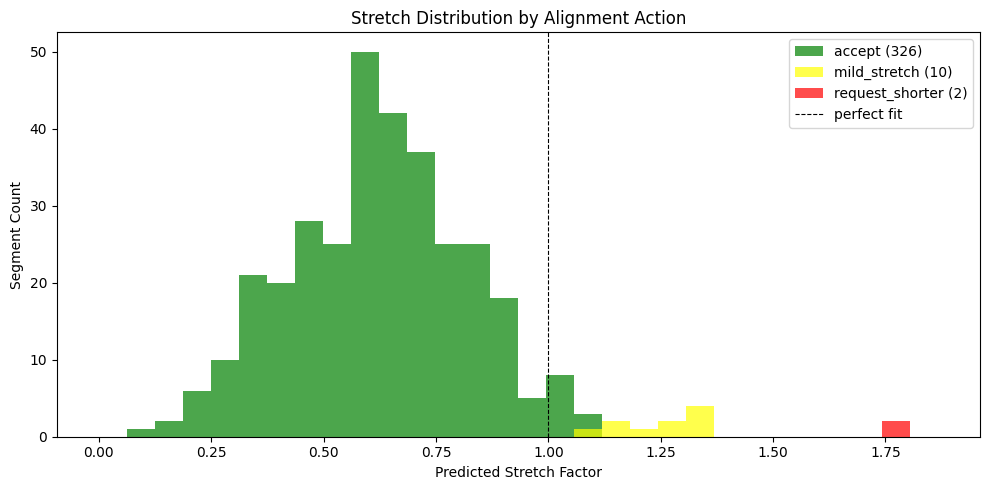

Saved to /home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers/notebooks/alignment_integration/images/stretch_distribution.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

stretches = [m.predicted_stretch for m in all_metrics]
actions = [decide_action(m) for m in all_metrics]

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}
colors = [color_map[a] for a in actions]

fig, ax = plt.subplots(figsize=(10, 5))

# Group by action for legend
for action in AlignAction:
    vals = [s for s, a in zip(stretches, actions) if a == action]
    if vals:
        ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                label=f"{action.value} ({len(vals)})", range=(0, max(stretches) * 1.05))

ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
ax.set_xlabel("Predicted Stretch Factor")
ax.set_ylabel("Segment Count")
ax.set_title("Stretch Distribution by Alignment Action")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution.png'}")

---

## Task 1: Improve TTS Duration Prediction

The stretch factors above rely on a crude heuristic: ~15 characters/second for Spanish. Look at the worst segments — the heuristic is often wrong because character count ignores syllable structure, pauses, and speaking rate.

**Goal:** Replace the heuristic with a better duration predictor and measure whether it reduces alignment errors.

**Approach:**
1. Collect ground-truth durations by running TTS on a sample of segments and measuring actual WAV duration
2. Compare predictors: character count, syllable count (use a Spanish syllabifier), and a simple regression model trained on (text features → actual TTS duration)
3. Plug your predictor into `compute_segment_metrics` by modifying the `predicted_tts_duration_s` calculation in `foreign_whispers/alignment.py`

**File to modify:** `foreign_whispers/alignment.py` — the `_estimate_duration` helper

**Evaluation:**
- Mean absolute duration error (predicted vs actual TTS output)
- Calibration: does the predictor work equally well for short and long utterances?
- Downstream: does the improved predictor change the action distribution (fewer `REQUEST_SHORTER` or `FAIL`)? Re-run the policy histogram below to check.

In [5]:
# Task 1: Baseline — measure how wrong the current heuristic is
# Compare predicted duration (chars/15) against actual TTS WAV durations

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    errors = []
    for seg in segments:
        predicted = seg["target_sec"]  # source window duration
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            errors.append(abs(predicted - actual))

    if errors:
        print(f"Segments with TTS ground truth: {len(errors)}")
        print(f"Mean absolute error:  {sum(errors)/len(errors):.2f}s")
        print(f"Max error:            {max(errors):.2f}s")
        print(f"\nThis is the baseline to beat with a better predictor.")
        print(f"Modify _estimate_duration() in foreign_whispers/alignment.py")
    else:
        print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")
else:
    print("No alignment reports found — run the TTS pipeline first")


Segments with TTS ground truth: 98
Mean absolute error:  2.68s
Max error:            5.78s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


In [6]:
all_metrics

[SegmentMetrics(index=0, source_start=4.88, source_end=10.879999999999999, source_duration_s=5.999999999999999, source_text='Very few people retire at the age of 16.', translated_text='Muy pocas personas se jubilan a los 16 años.', src_char_count=40, tgt_char_count=44, predicted_tts_s=3.691470995201677, predicted_stretch=0.6152451658669462, overflow_s=0.0),
 SegmentMetrics(index=1, source_start=8.4, source_end=13.599, source_duration_s=5.199, source_text='Then again, few people have careers with', translated_text='Entonces otra vez, pocas personas tienen carreras con', src_char_count=40, tgt_char_count=53, predicted_tts_s=4.355450095201676, predicted_stretch=0.8377476620891857, overflow_s=0.0),
 SegmentMetrics(index=2, source_start=10.88, source_end=16.64, source_duration_s=5.76, source_text='as many twists as American figure skater', translated_text='tantos giros como la figura americana skater', src_char_count=40, tgt_char_count=44, predicted_tts_s=3.7025859252016766, predicted_stret

In [7]:
my_errors = []
for seg in all_metrics:
    predicted = seg.predicted_tts_s  # source window duration
    actual = seg.source_duration_s
    if actual > 0:
        my_errors.append(abs(seg.predicted_tts_s - seg.source_duration_s))

if my_errors:
    print(f"Segments with TTS ground truth: {len(my_errors)}")
    print(f"Mean absolute error:  {sum(my_errors)/len(my_errors):.2f}s")
    print(f"Max error:            {max(my_errors):.2f}s")
else:
    print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")


Segments with TTS ground truth: 338
Mean absolute error:  1.76s
Max error:            5.81s


In [8]:
# MY EXPERIMENTS
from sklearn.linear_model import LinearRegression
import numpy as np
import re
import silabeador
from foreign_whispers.alignment import _count_syllables

# 1. Instantiate an empty model
model = LinearRegression()

def estimate_syllables(word: str) -> int:
    w = re.sub(r'[^a-z]', '', word.lower())
    if not w:
        return 0
    groups = re.findall(r'[aeiouy]+', w)
    s = len(groups)
    if w.endswith('e') and s > 1:
        s -= 1
    return max(1, s)

def embed_text(seg):
    text_x = seg['text']
    f1 = len(text_x)
    # f2 = seg['speed_factor'] # This feature not available in alignment.py
    # f2 = estimate_syllables(text_x)
    word_list = text_x.split()
    f3 = len(word_list)

    # words_len = [len(x) for x in word_list]
    # f4 = np.median(words_len)
    # f5 = np.std(words_len)
    # f6 = np.mean(words_len)
    # if text_x[0] == 'y':
    #     f6 = len(silabeador.syllabify(text_x[1:])) + 1
    # else:
    #     f6 = len(silabeador.syllabify(text_x))

    # f7 = np.max(words_len)
    f7 = _count_syllables(text_x)
    # f8 = np.min(words_len)

    # vector_embed = np.array([f1, f2, f3, f4, f5, f6, f7, f8])
    # vector_embed = np.array([f1, f2, f3, f4, f5, f6])
    # vector_embed = np.array([f1, f2, f3, f6])
    # vector_embed = np.array([f1, f2, f3, f6, f7])
    vector_embed = np.array([f1, f3, f7])
    return vector_embed

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    dataset_x = []
    dataset_y = []
    for seg in segments:
        dataset_y.append(seg['raw_duration_s'])
        dataset_x.append(embed_text(seg))

model.fit(dataset_x, dataset_y)

# See example, works!
pred_y = model.predict(
    [embed_text(
        {
            "index": 56,
            "text": "\u00bfen la calle de Hormuz?",
            "target_sec": 4.56,
            "stretch_factor": 1.0,
            "raw_duration_s": 1.94,
            "speed_factor": 0.425,
            "action": "unknown"
            # [2.22186804]
        }
    )]
)

# print(dataset_x)

print(pred_y)
print(f"Model Params:")
print(model.coef_)
print(model.intercept_)
# Copy to alignment.py

[0.36267712]
Model Params:
[-9.09898792e-05 -1.32209701e-02  4.21738326e-02]
0.1356579048307069


## Alignment Fallback Policy

| Stretch Factor | Action            | Description                                |
|----------------|-------------------|--------------------------------------------|
| <= 1.1         | ACCEPT            | Fits naturally, no change needed           |
| 1.1 - 1.4     | MILD_STRETCH      | Apply pyrubberband time-stretch            |
| 1.4 - 1.8     | GAP_SHIFT         | Borrow from adjacent silence gap           |
| 1.8 - 2.5     | REQUEST_SHORTER   | Request a shorter translation              |
| > 2.5         | FAIL              | Unfixable, fall back to silence            |

In [9]:
action_counts = {a: 0 for a in AlignAction}
for m in all_metrics:
    action_counts[decide_action(m)] += 1

print("Policy distribution:")
for action, count in action_counts.items():
    bar = "\u2588" * count
    print(f"  {action.value:<20} {count:3d}  {bar}")

Policy distribution:
  accept               326  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  mild_stretch          10  ██████████
  gap_shift              0  
  request_shorter        2  ██
  fail                   0  


---

## Task 2: Duration-Aware Translation Re-ranking

Look at the histogram above. Every segment tagged `REQUEST_SHORTER` or `FAIL` is a segment where the Spanish translation is too long to speak in the available time window. The translator doesn't know about duration — it just rewrites text.

**Goal:** For segments that exceed the timing budget, generate shorter translation candidates and pick the one that best fits the source window while preserving meaning.

**Approach:**
1. Filter `all_metrics` for segments where `decide_action(m)` returns `REQUEST_SHORTER`
2. For each, generate 2–3 shorter Spanish alternatives (options: rule-based truncation, LLM candidate generation, or back-translation filtering)
3. Score candidates by: `(predicted_duration - target_duration)² + λ * semantic_distance`
4. Implement this in `foreign_whispers/reranking.py` — the `get_shorter_translations()` stub

**File to modify:** `foreign_whispers/reranking.py`

**Evaluation:**
- How many `REQUEST_SHORTER` segments can you bring down to `MILD_STRETCH` or `ACCEPT`?
- Semantic preservation: compare original and shortened translations using embedding cosine similarity
- Re-run the policy histogram above with your improved translations to measure the shift

In [10]:
# Task 2: Identify the segments that need shorter translations
# These are your targets for re-ranking

over_budget = [m for m in all_metrics if decide_action(m) in (AlignAction.REQUEST_SHORTER, AlignAction.FAIL)]

print(f"Segments needing shorter translations: {len(over_budget)}")
print(f"\nExamples (worst 3):")
for m in sorted(over_budget, key=lambda x: -x.predicted_stretch)[:3]:
    source_dur = m.source_duration_s
    predicted_tts = m.predicted_tts_s
    print(f"\n  seg {m.index}  source_window={source_dur:.1f}s  predicted_tts={predicted_tts:.1f}s  stretch={m.predicted_stretch:.2f}x")

    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {source_dur:.1f}s → need ~{int(source_dur * 15)} chars or fewer")

Segments needing shorter translations: 2

Examples (worst 3):

  seg 197  source_window=1.9s  predicted_tts=3.4s  stretch=1.78x
    EN: >> And are you thinking this is a terrible
    ES: > Y estás pensando que esto es terrible
    Target: fit TTS into 1.9s → need ~28 chars or fewer

  seg 225  source_window=2.0s  predicted_tts=3.5s  stretch=1.77x
    EN: >> And how did dad react when you told him
    ES: > Y cómo reaccionó papá cuando le dijiste
    Target: fit TTS into 2.0s → need ~30 chars or fewer


### Testing Implementation
#### Semantics

In [11]:
from foreign_whispers.reranking import get_shorter_translations

for m in sorted(over_budget, key=lambda x: -x.predicted_stretch):
    print(f"\n  seg {m.index}  source_window={m.source_duration_s:.1f}s  predicted_tts={m.predicted_tts_s:.1f}s  stretch={m.predicted_stretch:.2f}x")

    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {m.source_duration_s:.1f}s → need ~{int(m.source_duration_s * 15)} chars or fewer")

    candidates = get_shorter_translations(m.source_text, m.translated_text, m.source_duration_s)
    print(f"{candidates[0]}")


  seg 197  source_window=1.9s  predicted_tts=3.4s  stretch=1.78x
    EN: >> And are you thinking this is a terrible
    ES: > Y estás pensando que esto es terrible
    Target: fit TTS into 1.9s → need ~28 chars or fewer


/home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


¿Y estás pensando que esto es terrible?
Candidate: ¿Y estás pensando que esto es terrible?, Score: 2.305560023276769
Y estás pensando que esto es terrible
Candidate: Y estás pensando que esto es terrible, Score: 1.848767391562397
Y estás pensando que esto es una terrible
Candidate: Y estás pensando que esto es una terrible, Score: 2.6585954727231313
TranslationCandidate(text='Y estás pensando que esto es terrible', char_count=37, brevity_rationale='None')

  seg 225  source_window=2.0s  predicted_tts=3.5s  stretch=1.77x
    EN: >> And how did dad react when you told him
    ES: > Y cómo reaccionó papá cuando le dijiste
    Target: fit TTS into 2.0s → need ~30 chars or fewer
Y cómo reaccionó papá cuando le dijiste
Candidate: Y cómo reaccionó papá cuando le dijiste, Score: 1.9712407234391458
¿Y cómo reaccionó papá cuando se lo dijiste?
Candidate: ¿Y cómo reaccionó papá cuando se lo dijiste?, Score: 3.10545204495616
¿Y cómo reaccionó papá cuando le dijiste
Candidate: ¿Y cómo reaccionó pap

In [12]:
import copy
# Recreate the reranked transcript
es_transcript_reranked = copy.deepcopy(es_transcript)
rerank_records = []  # for downstream metrics + semantic-similarity reporting

for m in sorted(over_budget, key=lambda x: -x.predicted_stretch):
    candidates = get_shorter_translations(
        m.source_text, m.translated_text, m.source_duration_s,
    )
    if not candidates:
        continue
    chosen = candidates[0]
    # Update the reranked transcript
    es_transcript_reranked["segments"][m.index]["text"] = chosen.text
    rerank_records.append({
        "index": m.index,
        "source_text": m.source_text,
        "baseline_es": m.translated_text,
        "shortened_es": chosen.text,
        "target_s": m.source_duration_s,
        "baseline_chars": len(m.translated_text),
        "shortened_chars": len(chosen.text),
    })

print(f"Re-ranked {len(rerank_records)} of {len(over_budget)} over-budget segments")
print(f"\nMean baseline chars : {sum(r['baseline_chars'] for r in rerank_records) / max(len(rerank_records), 1):.1f}")
print(f"Mean shortened chars: {sum(r['shortened_chars'] for r in rerank_records) / max(len(rerank_records), 1):.1f}")

¿Y estás pensando que esto es terrible?
Candidate: ¿Y estás pensando que esto es terrible?, Score: 2.305560023276769
Y estás pensando que esto es terrible
Candidate: Y estás pensando que esto es terrible, Score: 1.848767391562397
Y estás pensando que esto es una terrible
Candidate: Y estás pensando que esto es una terrible, Score: 2.6585954727231313
Y cómo reaccionó papá cuando le dijiste
Candidate: Y cómo reaccionó papá cuando le dijiste, Score: 1.9712407234391458
¿Y cómo reaccionó papá cuando se lo dijiste?
Candidate: ¿Y cómo reaccionó papá cuando se lo dijiste?, Score: 3.10545204495616
¿Y cómo reaccionó papá cuando le dijiste
Candidate: ¿Y cómo reaccionó papá cuando le dijiste, Score: 2.195298582149327
Re-ranked 2 of 2 over-budget segments

Mean baseline chars : 40.0
Mean shortened chars: 38.0


#### Conversions

In [13]:
# Recompute metrics with the re-ranked ES transcript and compare action counts.

from collections import Counter

# Recompute metrics with the re-ranked ES transcript and compare action counts.
new_metrics = compute_segment_metrics(en_transcript, es_transcript_reranked)
new_actions = [decide_action(m) for m in new_metrics]
old_actions = [decide_action(m) for m in all_metrics]

# Compare action counts before and after re-ranking.
old_counts = Counter(a.value for a in old_actions)
new_counts = Counter(a.value for a in new_actions)

print(f"{'Action':<20} {'Before':>8} {'After':>8} {'Delta':>8}")
for a in AlignAction:
    b = old_counts.get(a.value, 0)
    n = new_counts.get(a.value, 0)
    print(f"  {a.value:<18} {b:>8} {n:>8} {n - b:+8d}")

# Track which over-budget segments actually moved category
moved_out = []
for r in rerank_records:
    old_act = old_actions[r["index"]]
    new_act = new_actions[r["index"]]
    if old_act != new_act:
        moved_out.append((r["index"], old_act.value, new_act.value))

print(f"\n{len(moved_out)} of {len(rerank_records)} re-ranked segments moved out of REQUEST_SHORTER:")
for idx, old_a, new_a in moved_out:
    print(f"  seg {idx:3d}: {old_a} -> {new_a}")

Muy pocas personas se jubilan a los 16 años.
Entonces otra vez, pocas personas tienen carreras con
tantos giros como la figura americana skater
Alysa Leu. Después de ser el más joven
Campeón de mujeres de Estados Unidos en la historia a la edad
13, el Phenom sorprendió al mundo patinante
cuando abandonó abruptamente unos años
más tarde. Ahora 20 años, Alyssa ha vuelto.
y un favorito para ganar oro en el invierno
Olimpiadas el próximo mes. Su regreso a la
el deporte era casi tan sorprendente como ella
Salir de ella. Nadie sabía qué
espera cuando empezó a entrenar de nuevo,
pero de alguna manera en una noche del viernes pasado
Marcha en Boston, Alyssa Leu estaba liderando
en el Campeonato Mundial con uno
rendimiento para ir.
Era la patinadora final de la noche. A
El título mundial colgó en el equilibrio.
En segundos, estaba claro que estaba levantada.
hasta el momento
mientras la disco de Donna Summer pulsaba.
Alyssa Leu belissfully dashed around the
hielo, tejiendo combinaciones de salt

#### Plot Comparison

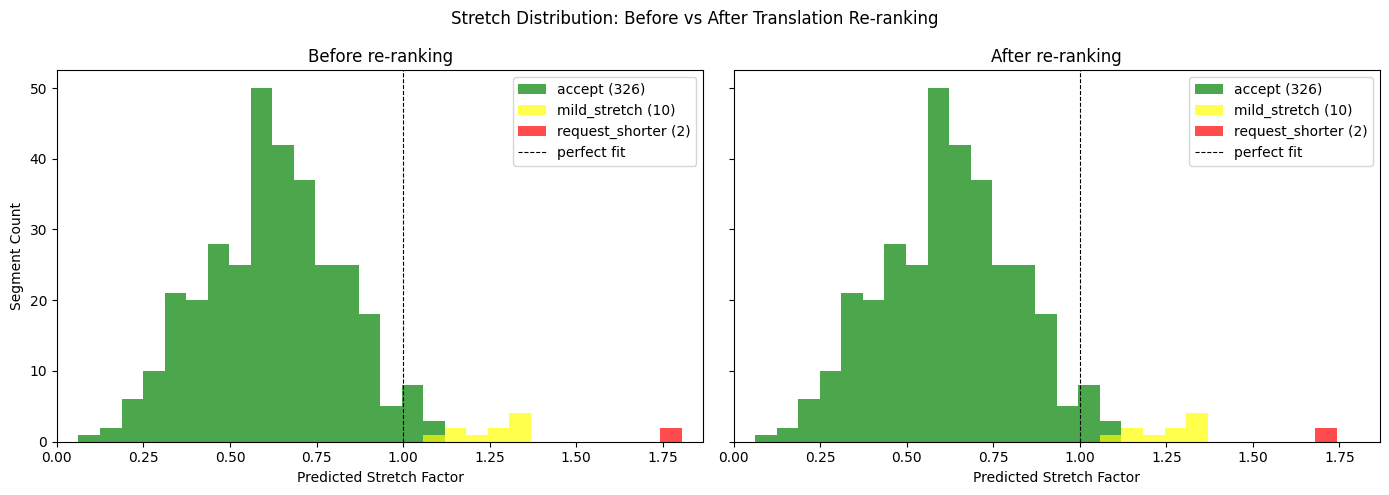

Saved to /home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers/notebooks/alignment_integration/images/stretch_distribution_after.png


In [14]:
# Re-plot the policy histogram side-by-side: original vs post-rerank.

import matplotlib.pyplot as plt

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}

old_stretches = [m.predicted_stretch for m in all_metrics]
new_stretches = [m.predicted_stretch for m in new_metrics]

x_max = max(max(old_stretches), max(new_stretches)) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, stretches, actions, title in [
    (axes[0], old_stretches, old_actions, "Before re-ranking"),
    (axes[1], new_stretches, new_actions, "After re-ranking"),
]:
    for action in AlignAction:
        vals = [s for s, a in zip(stretches, actions) if a == action]
        if vals:
            ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                    label=f"{action.value} ({len(vals)})", range=(0, x_max))
    ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
    ax.set_xlabel("Predicted Stretch Factor")
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0, x_max)

axes[0].set_ylabel("Segment Count")
fig.suptitle("Stretch Distribution: Before vs After Translation Re-ranking")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution_after.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution_after.png'}")

## Global Timeline Alignment

Optimizer that shifts segments into available silence gaps instead of forcing local stretches.
Uses a greedy left-to-right pass tracking cumulative drift from gap shifts.

In [15]:
from foreign_whispers import global_align

silence_regions = []  # Would come from VAD if silero-vad installed
aligned_segments = global_align(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 10
Total drift    : 0.00s


## Visualize Alignment Timeline

Plot original vs scheduled timing for each segment.

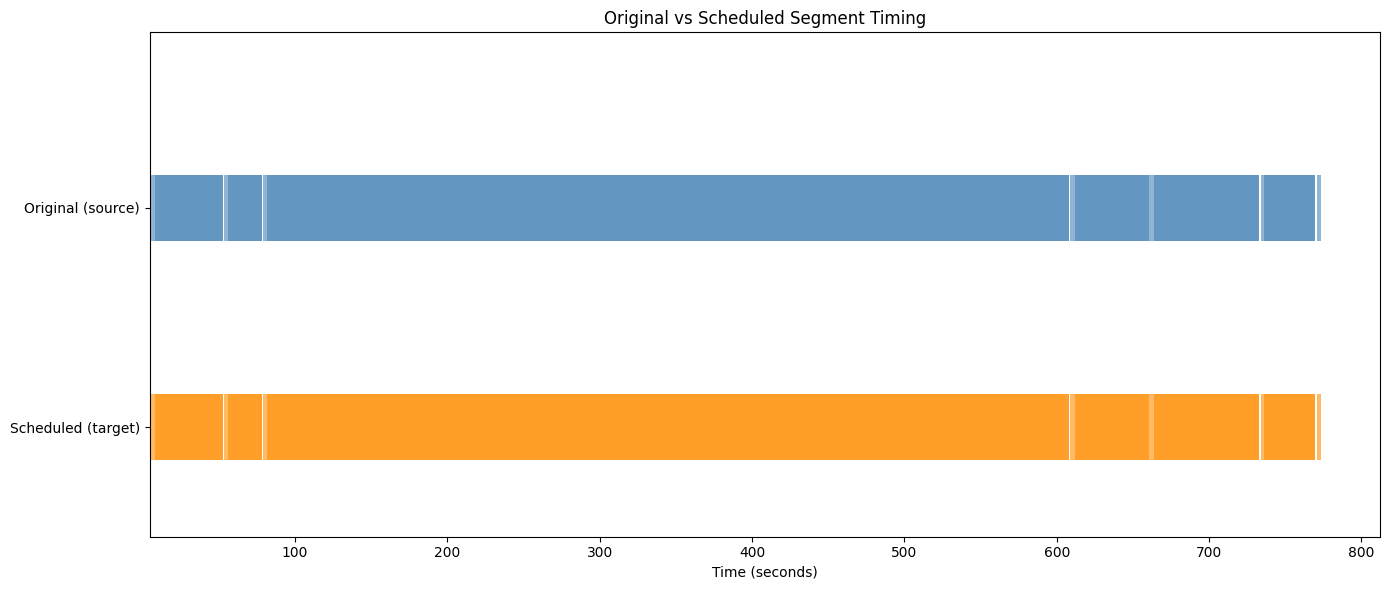

Saved to /home/william-zheng/Documents/Programming/Python/AI_course/foreign-whispers/notebooks/alignment_integration/images/alignment_timeline.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

y_original = 1
y_scheduled = 0

for seg in aligned_segments:
    # Original timing (blue)
    ax.barh(y_original, seg.original_end - seg.original_start,
            left=seg.original_start, height=0.3, color="steelblue", alpha=0.6,
            edgecolor="none")
    # Scheduled timing (orange)
    ax.barh(y_scheduled, seg.scheduled_end - seg.scheduled_start,
            left=seg.scheduled_start, height=0.3, color="darkorange", alpha=0.6,
            edgecolor="none")

ax.set_yticks([y_scheduled, y_original])
ax.set_yticklabels(["Scheduled (target)", "Original (source)"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Original vs Scheduled Segment Timing")
ax.set_ylim(-0.5, 1.8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "alignment_timeline.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'alignment_timeline.png'}")

---

## Task 3: Beat the Greedy Optimizer

The timeline above was produced by `global_align()` — a greedy left-to-right pass. It makes locally optimal decisions but can't look ahead. A segment that borrows silence early may starve a later segment that needed it more.

**Goal:** Implement a better global optimizer and compare it against the greedy baseline.

**Approach:**
1. Record the greedy baseline metrics: total drift, number of gap shifts, number of segments still in `REQUEST_SHORTER` or `FAIL` after alignment
2. Implement one of these alternatives in a new function (e.g. `global_align_dp` in `foreign_whispers/alignment.py`):
   - **Dynamic programming:** minimize total stretch penalty over all segments, subject to non-overlapping constraints
   - **Integer linear programming:** formulate as an optimization problem with scipy or PuLP — decision variables are per-segment time allocations, constraints enforce non-overlap and silence budgets
   - **Beam search:** explore multiple scheduling trajectories, prune by cumulative drift
3. Compare your optimizer against the greedy baseline on the same clip

**File to modify:** `foreign_whispers/alignment.py` — add your optimizer alongside `global_align`

**Evaluation:**
- Total cumulative drift (lower is better)
- Number of segments requiring severe stretch (>1.4x)
- Number of segments that overlap in the scheduled timeline
- Re-plot the timeline visualization above with your optimizer's output

In [17]:
# Task 3: Record the greedy baseline to compare against your optimizer

from foreign_whispers import clip_evaluation_report

greedy_report = clip_evaluation_report(all_metrics, aligned_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print(f"\nYour optimizer should improve on these numbers.")
print(f"Add global_align_dp() to foreign_whispers/alignment.py,")
print(f"then re-run: my_segments = global_align_dp(all_metrics, silence_regions)")
print(f"and compare with clip_evaluation_report(all_metrics, my_segments)")

=== Greedy Baseline ===
  mean_abs_duration_error_s: 1.756
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 2
  total_cumulative_drift_s: 0.0

Your optimizer should improve on these numbers.
Add global_align_dp() to foreign_whispers/alignment.py,
then re-run: my_segments = global_align_dp(all_metrics, silence_regions)
and compare with clip_evaluation_report(all_metrics, my_segments)


### Implementation

In [18]:
from foreign_whispers.alignment import global_align_dp

silence_regions = []  # Would come from VAD if silero-vad installed
aligned_segments = global_align_dp(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 12
Total drift    : 0.00s


---

## Task 4: Build a Dubbing Quality Scorecard

The `clip_evaluation_report()` above gives you five numbers. But dubbing quality is multi-dimensional — timing accuracy is necessary but not sufficient. A clip with perfect timing but garbled speech is still a failure.

**Goal:** Design and implement a richer evaluation framework that scores clips across multiple dimensions.

**Dimensions to consider:**
- **Timing accuracy:** mean absolute duration error, percentage of severe stretches, cumulative drift (you already have these)
- **Intelligibility:** can you use a speech-to-text round-trip? TTS the Spanish, then STT it back — compare against the translation. Word error rate of the round-trip measures intelligibility.
- **Semantic fidelity:** how much meaning was lost? Compare source English and back-translated English using embedding cosine similarity
- **Naturalness:** speaking rate variance across segments — is it consistent or does it jump between fast and slow?

**Approach:**
1. Implement `dubbing_scorecard(metrics, aligned_segments, align_report)` in `foreign_whispers/evaluation.py`
2. Return a dict with scores per dimension, each normalized to [0, 1]
3. Add a summary visualization — a radar chart or bar chart comparing baseline vs aligned

**File to modify:** `foreign_whispers/evaluation.py`

**Evaluation:**
- Does your scorecard distinguish between good and bad clips?
- Do the dimensions correlate with each other, or do they capture independent quality aspects?
- Run on multiple videos from `video_registry.yml` and compare

---

## Summary

Alignment is pure Python, no GPU required. All the timing analysis, policy decisions,
and global scheduling run on CPU with zero external dependencies beyond stdlib.

### Task overview

| Task | What you build | File to modify | Evaluation |
|------|---------------|----------------|------------|
| 1. Duration Prediction | Better TTS duration estimator | `alignment.py` — `_estimate_duration` | Mean absolute error vs ground truth |
| 2. Translation Re-ranking | Shorter candidates that fit the timing budget | `reranking.py` — `get_shorter_translations` | Segments moved from `REQUEST_SHORTER` to `ACCEPT` |
| 3. Global Optimizer | DP/ILP/search optimizer that beats greedy | `alignment.py` — new `global_align_dp` | Total drift, severe stretch count |
| 4. Quality Scorecard | Multi-dimensional evaluation framework | `evaluation.py` — new `dubbing_scorecard` | Dimension independence, cross-clip consistency |

Each task builds on the analysis you ran above and uses data already in `pipeline_data/`.
Validate your results end-to-end by re-running the TTS and stitch notebooks.

### Cross-notebook connections

- **Speaker-aware alignment** — the `diarization_integration` notebook labels speaker turns.
  Feed that signal into your optimizer to prevent borrowing silence across speaker boundaries.
- **Voice cloning** — the `tts_integration` notebook wires per-speaker voice selection.
  Combined with diarization, different speakers get different voices.
